# Install the `datasets` library

In [4]:
!pip install datasets

# Import necessary libraries

In [5]:
# Import necessary libraries for data manipulation, visualization, and machine learning
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, VotingClassifier

# Load the churn prediction dataset from scikit-learn

In [6]:
# Load the churn prediction dataset from the scikit-learn collection in the datasets library
from datasets import load_dataset

ds = load_dataset("scikit-learn/churn-prediction")

c:\Users\balar\OneDrive\Desktop\Projects\ML\Customer churn prediction\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\balar\OneDrive\Desktop\Projects\ML\Customer churn prediction\.venv\Lib\site-packages\huggingface_hub\file_download.py:121: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\balar\.cache\huggingface\hub\datasets--scikit-learn--churn-prediction. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need 

# Convert the dataset to a pandas DataFrame

In [7]:
# Convert the 'train' split of the dataset to a pandas DataFrame
df = ds['train'].to_pandas()

# Display the first 5 rows of the DataFrame

In [8]:
# Display the first 5 rows of the DataFrame to get a glimpse of the data
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Get information about the DataFrame, including data types and non-null counts

In [9]:
# Print a concise summary of the DataFrame, showing column names, non-null counts, and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


# Generate descriptive statistics for the numerical columns

In [10]:
# Generate descriptive statistics for numerical columns in the DataFrame
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


# Print unique values for each column

In [11]:
# Iterate through each column and print the column name and its unique values
columns=df.columns
for i in columns:
  print(i)
  print(df[i].unique())
  print("-"*34)

customerID
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
----------------------------------
gender
['Female' 'Male']
----------------------------------
SeniorCitizen
[0 1]
----------------------------------
Partner
['Yes' 'No']
----------------------------------
Dependents
['No' 'Yes']
----------------------------------
tenure
[ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
----------------------------------
PhoneService
['No' 'Yes']
----------------------------------
MultipleLines
['No phone service' 'No' 'Yes']
----------------------------------
InternetService
['DSL' 'Fiber optic' 'No']
----------------------------------
OnlineSecurity
['No' 'Yes' 'No internet service']
----------------------------------
OnlineBackup
['Yes' 'No' 'No internet service']
--------------------

# Check for missing values in each column

In [12]:
# Calculate and display the sum of missing values for each column
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

# Generate descriptive statistics for object (categorical) columns

In [13]:
# Generate descriptive statistics for columns with object data type
df.describe(include=['object'])

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


# Visualize the distribution of 'tenure' and 'MonthlyCharges'

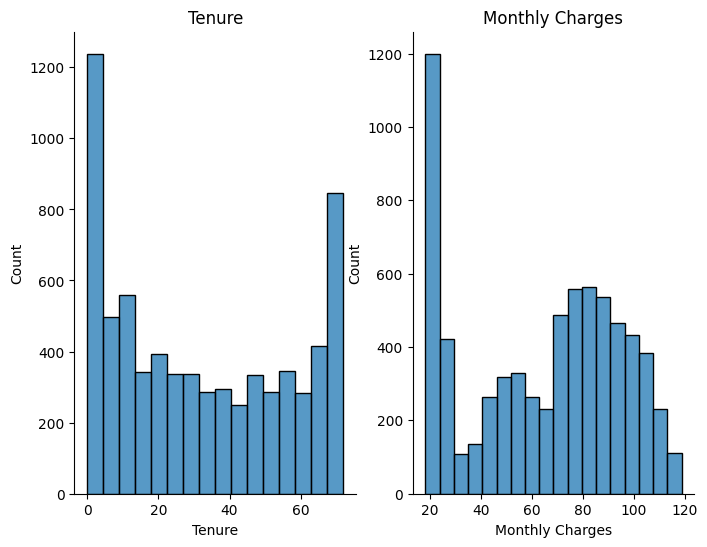

In [14]:
# Create histograms to visualize the distribution of 'tenure' and 'MonthlyCharges'
plt.style.use({
    'axes.spines.top': False,
    'axes.spines.right': False,
})
f,ax=plt.subplots(1,2,figsize=(8,6))
sns.histplot(data=df, x='tenure',ax=ax[0])
ax[0].set_title("Tenure")
ax[0].set_xlabel("Tenure")
ax[0].set_ylabel("Count")
sns.histplot(data=df, x='MonthlyCharges',ax=ax[1])
ax[1].set_title("Monthly Charges")
ax[1].set_xlabel("Monthly Charges")
ax[1].set_ylabel("Count")
plt.show()

# Visualize the distribution of 'gender' and 'SeniorCitizen' using pie charts

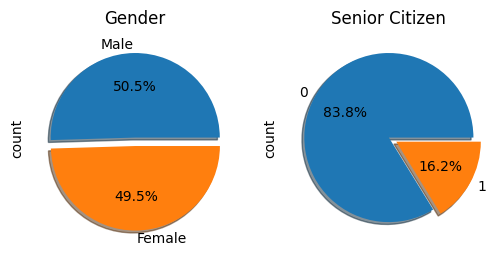

In [15]:
# Create pie charts to visualize the distribution of 'gender' and 'SeniorCitizen'
f,ax=plt.subplots(1,2,figsize=(6,6))
df["gender"].value_counts().plot.pie(explode=[0, 0.1], autopct='%1.1f%%', ax=ax[0], shadow=True)
ax[0].set_title("Gender")
df["SeniorCitizen"].value_counts().plot.pie(explode=[0, 0.1], autopct='%1.1f%%', ax=ax[1], shadow=True)
ax[1].set_title("Senior Citizen")
plt.show()

# Encode categorical columns using Label Encoding and One-Hot Encoding

In [16]:
# Define columns for label encoding and one-hot encoding
label_encoding_columns=['gender','Partner','Dependents','PhoneService','PaperlessBilling','Churn']
one_hot_encoding_columns=['MultipleLines','InternetService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','Contract','PaymentMethod']
# Initialize LabelEncoder and apply it to specified columns
label_encoder=LabelEncoder()
for i in label_encoding_columns:
  df[i]=label_encoder.fit_transform(df[i])
# Apply one-hot encoding to specified columns, dropping the first category to avoid multicollinearity
df = pd.get_dummies(df, columns=[
    'MultipleLines', 'InternetService', 'OnlineSecurity',
    'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod'
],drop_first=True,sparse=True)
# Display the first 5 rows of the modified DataFrame
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,0,0,1,0,1,0,1,29.85,29.85,...,False,False,False,False,False,False,False,False,True,False
1,5575-GNVDE,1,0,0,0,34,1,0,56.95,1889.5,...,False,False,False,False,False,True,False,False,False,True
2,3668-QPYBK,1,0,0,0,2,1,1,53.85,108.15,...,False,False,False,False,False,False,False,False,False,True
3,7795-CFOCW,1,0,0,0,45,0,0,42.30,1840.75,...,True,False,False,False,False,True,False,False,False,False
4,9237-HQITU,0,0,0,0,2,1,1,70.70,151.65,...,False,False,False,False,False,False,False,False,True,False


# Visualize the distribution of 'Churn' and the relationship between 'Churn' and 'gender'

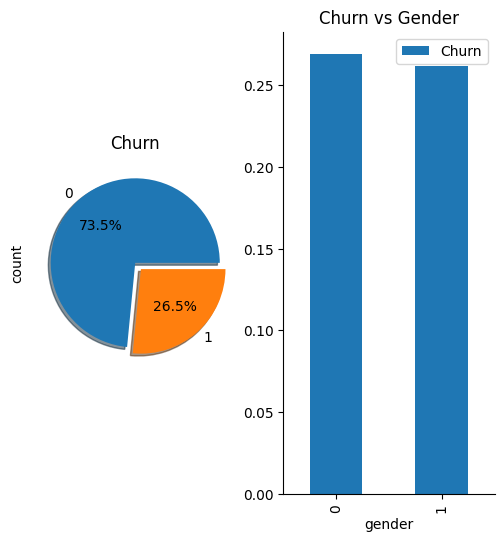

In [17]:
# Create a pie chart to visualize the distribution of the 'Churn' column
f,ax=plt.subplots(1,2,figsize=(6,6))
df['Churn'].value_counts().plot.pie(explode=[0, 0.1], autopct='%1.1f%%', shadow=True,ax=ax[0])
ax[0].set_title("Churn")
# Create a bar plot to show the relationship between 'Churn' and 'gender'
df[['Churn','gender']].groupby(['gender']).mean().plot.bar(ax=ax[1])
ax[1].set_title("Churn vs Gender")
plt.show()

# Visualize the correlation matrix of numerical columns

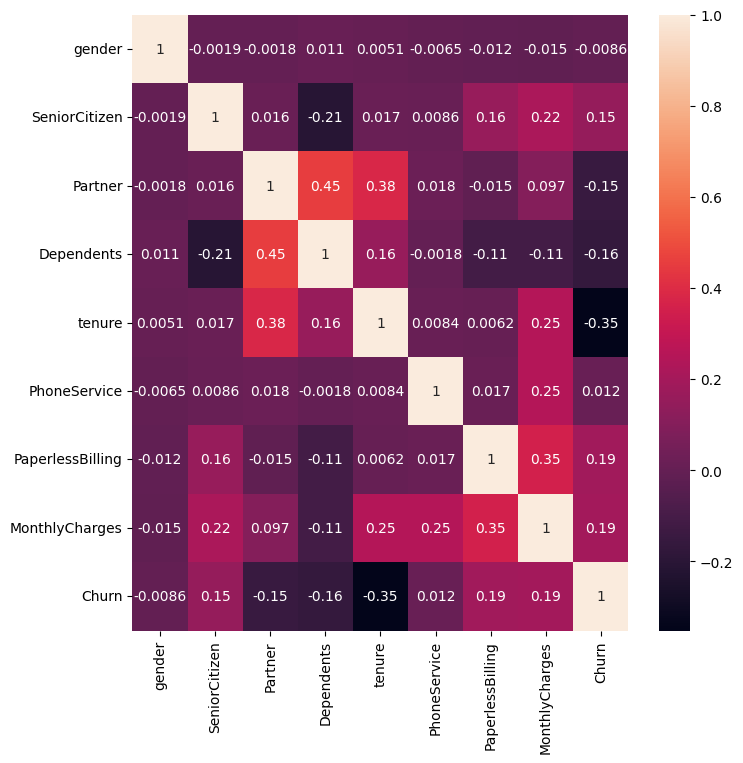

In [18]:
# Select numerical columns and calculate the correlation matrix
numarical_columns=df.select_dtypes(include=['number']).columns
correlation=df[numarical_columns].corr()
# Create a heatmap to visualize the correlation matrix
plt.figure(figsize=(8,8))
sns.heatmap(correlation,annot=True)
plt.show()

In [19]:
# Split the DataFrame into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(df.drop('Churn', axis=1), df['Churn'], test_size=0.2, random_state=42)

#### Data Cleaning: Convert 'TotalCharges' to numeric and handle missing values, and drop 'customerID'

In [20]:
# Convert 'TotalCharges' to numeric, coercing errors to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Impute missing values in 'TotalCharges' with the mean
df['TotalCharges'].fillna(df['TotalCharges'].mean(), inplace=True)

# Drop the 'customerID' column as it's a unique identifier and not a feature
# Check if 'customerID' column exists before dropping
if 'customerID' in df.columns:
    df.drop('customerID', axis=1, inplace=True)

# Verify the data types and check for any remaining missing values
print("DataFrame Info after cleaning:")
df.info()
print("\nMissing values after cleaning:")
print(df.isnull().sum())

DataFrame Info after cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype              
---  ------                                 --------------  -----              
 0   gender                                 7043 non-null   int64              
 1   SeniorCitizen                          7043 non-null   int64              
 2   Partner                                7043 non-null   int64              
 3   Dependents                             7043 non-null   int64              
 4   tenure                                 7043 non-null   int64              
 5   PhoneService                           7043 non-null   int64              
 6   PaperlessBilling                       7043 non-null   int64              
 7   MonthlyCharges                         7043 non-null   float64            
 8   TotalCharges                           7043 non-null   fl

C:\Users\balar\AppData\Local\Temp\ipykernel_8676\3228642021.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].mean(), inplace=True)
C:\Users\balar\AppData\Local\Temp\ipykernel_8676\3228642021.py:14: FutureWarning: Allowing arbitrary scalar fill_value in SparseDtype is deprecated. In a future version, the fill_value must be a valid value for the SparseDtype.subtype.
  df.info()
C:\Users\balar\AppData\Local\Temp\ipykernel_8676\3228642021.py:16: FutureWarning: Allowing arbitrary scal

In [21]:
X_train, X_test, y_train, y_test = train_test_split(df.drop('Churn', axis=1), df['Churn'], test_size=0.2, random_state=42)

# Train and evaluate different classification models

In [22]:
models={
    'Decision Tree':DecisionTreeClassifier(),
    'Random Forest':RandomForestClassifier(),
    'voting_classifer':VotingClassifier(estimators=[('dt',DecisionTreeClassifier()),('rf',RandomForestClassifier())],voting='soft')
}
for i in range(len(list(models))):
  model=list(models.values())[i]
  model.fit(X_train,y_train)
  y_pred=model.predict(X_test)
  accuracy=accuracy_score(y_test,y_pred)
  print(list(models.keys())[i])
  print(accuracy)
  print("-"*34)

c:\Users\balar\OneDrive\Desktop\Projects\ML\Customer churn prediction\.venv\Lib\site-packages\sklearn\utils\validation.py:919: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
c:\Users\balar\OneDrive\Desktop\Projects\ML\Customer churn prediction\.venv\Lib\site-packages\sklearn\utils\validation.py:919: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
c:\Users\balar\OneDrive\Desktop\Projects\ML\Customer churn prediction\.venv\Lib\site-packages\sklearn\utils\validation.py:919: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


Decision Tree
0.7196593328601846
----------------------------------


c:\Users\balar\OneDrive\Desktop\Projects\ML\Customer churn prediction\.venv\Lib\site-packages\sklearn\utils\validation.py:919: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
c:\Users\balar\OneDrive\Desktop\Projects\ML\Customer churn prediction\.venv\Lib\site-packages\sklearn\utils\validation.py:919: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
c:\Users\balar\OneDrive\Desktop\Projects\ML\Customer churn prediction\.venv\Lib\site-packages\sklearn\utils\validation.py:919: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


Random Forest
0.7913413768630234
----------------------------------
voting_classifer
0.7154009936124911
----------------------------------


c:\Users\balar\OneDrive\Desktop\Projects\ML\Customer churn prediction\.venv\Lib\site-packages\sklearn\utils\validation.py:919: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
c:\Users\balar\OneDrive\Desktop\Projects\ML\Customer churn prediction\.venv\Lib\site-packages\sklearn\utils\validation.py:919: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


## Apply GridSearchCV only to Decision Tree and Random Forest models for hyperparameter tuning

In [23]:
param_grids = {
    'Decision Tree': {
        'max_depth': [None, 5, 10, 20],
        'min_samples_split': [2, 5, 10]
    },
    'Random Forest': {
        'n_estimators': [100, 300],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]
    },
    'voting_classifer': {}
}

In [24]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

models = {
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'voting_classifer': VotingClassifier(
        estimators=[
            ('dt', DecisionTreeClassifier()),
            ('rf', RandomForestClassifier())
        ],
        voting='soft'
    )
}

param_grids = {
    'Decision Tree': {
        'max_depth': [None, 5, 10, 20],
        'min_samples_split': [2, 5, 10]
    },

    'Random Forest': {
        'n_estimators': [100, 300],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]
    },

    'voting_classifer': {}     # No hyperparameter tuning for voting classifier
}

for model_name, model in models.items():

    print(model_name)
    print("-" * 34)

    # If no hyperparameters to tune
    if param_grids[model_name] == {}:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        print("Accuracy:", accuracy_score(y_test, y_pred))
        print()
        continue

    # Apply GridSearchCV
    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grids[model_name],
        scoring='accuracy',
        cv=5,
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    print("Best Params:", grid.best_params_)
    print("Best CV Accuracy:", grid.best_score_)

    # Evaluate on test data
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)
    print("Test Accuracy:", accuracy_score(y_test, y_pred))
    print()


Decision Tree
----------------------------------


c:\Users\balar\OneDrive\Desktop\Projects\ML\Customer churn prediction\.venv\Lib\site-packages\sklearn\utils\validation.py:919: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
c:\Users\balar\OneDrive\Desktop\Projects\ML\Customer churn prediction\.venv\Lib\site-packages\sklearn\utils\validation.py:919: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


Best Params: {'max_depth': 5, 'min_samples_split': 2}
Best CV Accuracy: 0.7855880447784953
Test Accuracy: 0.8062455642299503

Random Forest
----------------------------------


c:\Users\balar\OneDrive\Desktop\Projects\ML\Customer churn prediction\.venv\Lib\site-packages\sklearn\utils\validation.py:919: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


Best Params: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 300}
Best CV Accuracy: 0.8029813979804601
Test Accuracy: 0.8119233498935415

voting_classifer
----------------------------------


c:\Users\balar\OneDrive\Desktop\Projects\ML\Customer churn prediction\.venv\Lib\site-packages\sklearn\utils\validation.py:919: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
c:\Users\balar\OneDrive\Desktop\Projects\ML\Customer churn prediction\.venv\Lib\site-packages\sklearn\utils\validation.py:919: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
c:\Users\balar\OneDrive\Desktop\Projects\ML\Customer churn prediction\.venv\Lib\site-packages\sklearn\utils\validation.py:919: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


Accuracy: 0.7210787792760823



c:\Users\balar\OneDrive\Desktop\Projects\ML\Customer churn prediction\.venv\Lib\site-packages\sklearn\utils\validation.py:919: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
c:\Users\balar\OneDrive\Desktop\Projects\ML\Customer churn prediction\.venv\Lib\site-packages\sklearn\utils\validation.py:919: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


In [25]:
import joblib
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Re-initializing the GridSearchCV for Random Forest to ensure 'best_rf_model' is correctly defined
# This step ensures the best performing Random Forest model from tuning is available for saving.
rf_model = RandomForestClassifier(random_state=42) # Add random_state for reproducibility
rf_param_grid = {
    'n_estimators': [100, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
rf_grid = GridSearchCV(
    estimator=rf_model,
    param_grid=rf_param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1
)
rf_grid.fit(X_train, y_train)
best_rf_model = rf_grid.best_estimator_

# 1. Save the trained model to a file
filename = 'finalized_random_forest_model.joblib'
joblib.dump(best_rf_model, filename)
print(f"Model saved as {filename}")

# 2. Load the model from the file
loaded_model = joblib.load(filename)
print("Model loaded successfully!")

# 3. Make a prediction using the loaded model
# Taking the first sample from the test set for demonstration
sample_for_prediction = X_test.iloc[[0]]
prediction = loaded_model.predict(sample_for_prediction)

print(f"\nSample input for prediction:\n{sample_for_prediction.head()}")
print(f"Predicted Churn (0=No, 1=Yes): {prediction[0]}")
print(f"Actual Churn for this sample: {y_test.iloc[0]}")

c:\Users\balar\OneDrive\Desktop\Projects\ML\Customer churn prediction\.venv\Lib\site-packages\sklearn\utils\validation.py:919: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


Model saved as finalized_random_forest_model.joblib
Model loaded successfully!

Sample input for prediction:
     gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
185       0              0        1           0       1             0   

     PaperlessBilling  MonthlyCharges  TotalCharges  \
185                 1            24.8          24.8   

     MultipleLines_No phone service  ...  TechSupport_Yes  \
185                            True  ...            False   

     StreamingTV_No internet service  StreamingTV_Yes  \
185                            False            False   

     StreamingMovies_No internet service  StreamingMovies_Yes  \
185                                False                False   

     Contract_One year  Contract_Two year  \
185              False              False   

     PaymentMethod_Credit card (automatic)  PaymentMethod_Electronic check  \
185                                  False                            True   

     PaymentMeth

c:\Users\balar\OneDrive\Desktop\Projects\ML\Customer churn prediction\.venv\Lib\site-packages\sklearn\utils\validation.py:919: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


In [26]:
# Create a new DataFrame with a single row for prediction
# The column names and order should match the training data (X_train or X_test)
new_customer_data = pd.DataFrame({
    'gender': [0], # Female
    'SeniorCitizen': [1], # Yes
    'Partner': [0], # No
    'Dependents': [0], # No
    'tenure': [12], # 12 months
    'PhoneService': [1], # Yes
    'PaperlessBilling': [1], # Yes
    'MonthlyCharges': [75.0],
    'TotalCharges': [900.0],
    'MultipleLines_No phone service': [False],
    'MultipleLines_Yes': [True],
    'InternetService_Fiber optic': [True],
    'InternetService_No': [False],
    'OnlineSecurity_No internet service': [False],
    'OnlineSecurity_Yes': [False],
    'OnlineBackup_No internet service': [False],
    'OnlineBackup_Yes': [True],
    'DeviceProtection_No internet service': [False],
    'DeviceProtection_Yes': [False],
    'TechSupport_No internet service': [False],
    'TechSupport_Yes': [False],
    'StreamingTV_No internet service': [False],
    'StreamingTV_Yes': [True],
    'StreamingMovies_No internet service': [False],
    'StreamingMovies_Yes': [False],
    'Contract_One year': [False],
    'Contract_Two year': [False],
    'PaymentMethod_Credit card (automatic)': [True],
    'PaymentMethod_Electronic check': [False],
    'PaymentMethod_Mailed check': [False]
})

# Ensure the columns are in the same order as X_test
new_customer_data = new_customer_data[X_test.columns]

# Make a prediction using the loaded model
new_prediction = loaded_model.predict(new_customer_data)

print("\nNew customer input for prediction:\n")
display(new_customer_data)
print(f"\nPredicted Churn for the new customer (0=No, 1=Yes): {new_prediction[0]}")



New customer input for prediction:



,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,MultipleLines_No phone service,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,0,12,1,1,75.0,900.0,False,...,False,False,True,False,False,False,False,True,False,False



Predicted Churn for the new customer (0=No, 1=Yes): 1


Run the above cell to see a prediction for a new customer.

Run the above cell to see how to save, load, and use the trained model.